# Balanceo de clases y PCA

El Sprint 0 estableció un baseline **puro** (11 modelos con hiperparámetros por defecto, sin ningún tratamiento del desbalance, IR ≈ 7.2:1) sobre las **43 features no económicas** organizadas en 4 grupos geoquímicos (mayores, trazas inmóviles, pathfinders, LILE) + 2 indicadores de detección. El **ganador baseline** fue MLP con F2\_CV = 0.5432 (Recall\_CV = 0.5235).

En este sprint se abordan dos preguntas:

1. **¿El tratamiento del desbalance mejora el F2?** Se evalúan 7 estrategias: 5 de sobremuestreo/combinadas (ROS, SMOTE, BorderlineSMOTE, ADASYN, SMOTETomek), **pesos de clase** (`class_weight='balanced'` / `scale_pos_weight`) y la referencia sin balanceo. El sobremuestreo se aplica **dentro de cada fold** del CV vía `ImbPipeline` de imblearn — esto garantiza que no haya fuga de información del fold de validación al proceso de balanceo.
2. **¿PCA ayuda a los modelos?** A diferencia de un PCA global (que mezclaría en una misma componente elementos de génesis distinta), se aplica **PCA por bloques geoquímicos**: una proyección independiente para cada grupo (mayores / inmóviles / pathfinders / LILE), concatenando las componentes resultantes y dejando pasar los indicadores binarios sin transformar. Así cada componente conserva una interpretación geológica (variabilidad de alteración, litológica, del halo de pathfinders o de LILE). Se barren distintos niveles de varianza retenida por bloque, sin balanceo y con el mejor balanceo de cada modelo.

**Criterio de decisión:** F2\_CV 5-fold estratificada (misma métrica primaria del Sprint 0, que prioriza el Recall — no dejar escapar zonas de interés). El hold-out se evalúa una sola vez al final y solo con fines informativos.

## Configuración

In [1]:
import warnings, os, json, time, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (fbeta_score, f1_score, accuracy_score, precision_score,
                             recall_score, roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve, roc_curve, make_scorer)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ── Métrica de decisión: F2 (prioriza Recall; ver justificación en Sprint 0) ──
F2_SCORER = make_scorer(fbeta_score, beta=2)

# ── Directorios de salida (misma estructura que Sprint 0) ──
OUT = 'outputs_sprint1'
DIR_DATA    = f'{OUT}/data'
DIR_MODELS  = f'{OUT}/models'
DIR_FIG     = f'{OUT}/figures'
DIR_TAB     = f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ── Estilo de impresión ──
def coral(texto):
    '''Resalta texto en color coral para resultados clave.'''
    return f'\033[38;2;255;127;80m{texto}\033[0m'

print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint1


## Versiones de librerías

In [2]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__,
    'joblib': joblib.__version__,
}
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3


## Carga de artefactos del Sprint 0

Se cargan los artefactos persistidos por el Sprint 0: dataset procesado (43 features no económicas), índices del split train/test, los **grupos geoquímicos** (necesarios para el PCA por bloques) y el resumen con las métricas de referencia. **No se re-deriva el split ni se redefinen los modelos** — se reutilizan exactamente los mismos para garantizar la comparabilidad.

In [3]:
# ── Cargar resumen del Sprint 0 ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)

F2_SPRINT0 = RESUMEN_S0['f2_final']
FEATURES   = RESUMEN_S0['features']
GRUPOS     = RESUMEN_S0['grupos_geoquimicos']   # 4 grupos + indicadores

# ── Cargar dataset procesado ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

# ── Cargar índices del split (persistidos por S0) ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Ratio de desbalance del train (para scale_pos_weight de XGBoost) ──
SPW = float((y_train == 0).sum() / (y_train == 1).sum())

# ── Verificación de integridad ──
assert X_train.shape[1] == len(FEATURES), f'Nº features no coincide: {X_train.shape[1]} vs {len(FEATURES)}'
assert len(X_train) + len(X_test) == len(df), 'Tamaño de split no coincide con dataset'
assert sum(len(v) for v in GRUPOS.values()) == len(FEATURES), 'Los grupos no cubren todas las features'

print(f'Modelos: {len(MODELOS)} | Features: {len(FEATURES)}')
for g, cols in GRUPOS.items():
    print(f'  {g:35s}: {len(cols)} features')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')
print(f'scale_pos_weight (neg/pos en train) = {SPW:.2f}')
print(coral(f'F2_CV ganador Sprint 0: {F2_SPRINT0:.4f} ({RESUMEN_S0["mejor_modelo"]})'))

Modelos: 11 | Features: 43
  Mayores (alteración)               : 10 features
  Trazas inmóviles (litología)       : 15 features
  Trazas móviles (pathfinders)       : 11 features
  LILE/álcalis (alteración compl.)   : 5 features
  Indicadores de detección           : 2 features
Train: (1705, 43) dist={0: 1497, 1: 208}
Test : (427, 43) dist={0: 375, 1: 52}
scale_pos_weight (neg/pos en train) = 7.20
F2_CV ganador Sprint 0: 0.5432 (MLP)


## Funciones

Los clasificadores base se extraen directamente de los pipelines `.pkl` guardados por el Sprint 0 (`outputs_sprint0/models/`). La función `crear_clf()` carga el clasificador del pipeline persistido, garantizando que los hiperparámetros sean **exactamente** los mismos que produjeron el baseline. Con `pesos=True` se activa además el tratamiento del desbalance por **pesos de clase**: `class_weight='balanced'` para los modelos de sklearn que lo soportan y `scale_pos_weight` (ratio neg/pos del train) para XGBoost; KNN y MLP no soportan pesos de clase y quedan fuera de esa estrategia.

El sobremuestreo se aplica **dentro** de cada fold del CV 5-fold estratificado mediante `ImbPipeline` de imblearn. Esto evita fuga de información: los ejemplos sintéticos generados por SMOTE/ROS nunca contaminan el fold de validación.

In [4]:
# ── Cargar modelos del Sprint 0 ──
_modelos_s0 = {}
for nombre, ruta in RESUMEN_S0['modelos_guardados'].items():
    _modelos_s0[nombre] = joblib.load(ruta)
print(f'{len(_modelos_s0)} modelos cargados de outputs_sprint0/models/')

# Modelos que soportan pesos de clase (y cómo)
SOPORTA_PESOS = {
    'Reg. Logística': dict(class_weight='balanced'),
    'SVM (RBF)': dict(class_weight='balanced'),
    'Árbol de Decisión': dict(class_weight='balanced'),
    'Random Forest': dict(class_weight='balanced'),
    'ExtraTrees': dict(class_weight='balanced'),
    'HistGradientBoosting': dict(class_weight='balanced'),
    'LightGBM': dict(class_weight='balanced'),
    'CatBoost': dict(auto_class_weights='Balanced'),
    'XGBoost': None,   # usa scale_pos_weight (se asigna abajo)
    # KNN y MLP no soportan pesos de clase
}

def crear_clf(mod, pesos=False):
    '''Extrae el clasificador base del pipeline S0 (sin scaler) y devuelve un clon fresco.
    Con pesos=True aplica class_weight="balanced" / scale_pos_weight si el modelo lo soporta.'''
    from sklearn.base import clone
    pipe_s0 = _modelos_s0[mod]
    clf = clone(pipe_s0.named_steps['clf'])
    if pesos:
        if mod == 'XGBoost':
            clf.set_params(scale_pos_weight=SPW)
        elif mod in SOPORTA_PESOS:
            clf.set_params(**SOPORTA_PESOS[mod])
        else:
            raise ValueError(f'{mod} no soporta pesos de clase')
    return clf

def crear_balanceador(nombre):
    '''Instancia el sobremuestreador indicado. Devuelve None para métodos sin remuestreo.'''
    if nombre in ('Sin balanceo', 'Pesos de clase'): return None
    if nombre == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if nombre == 'SMOTE':             return SMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'BorderlineSMOTE':   return BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'ADASYN':            return ADASYN(random_state=SEED)
    if nombre == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(nombre)

BALANCEADORES = ['Sin balanceo', 'Pesos de clase', 'RandomOverSampler', 'SMOTE',
                 'BorderlineSMOTE', 'ADASYN', 'SMOTETomek']

def soporta(mod, balanceo):
    '''¿El modelo soporta la estrategia? (solo restringe "Pesos de clase").'''
    return balanceo != 'Pesos de clase' or mod in SOPORTA_PESOS

def construir_pipeline(mod, balanceo='Sin balanceo', prep=None):
    '''ImbPipeline: StandardScaler|prep_bloques → (sobremuestreo) → clasificador.
    El preprocesado y el sobremuestreo se reajustan DENTRO de cada fold de CV (sin fuga).
    "Pesos de clase" no remuestrea: activa class_weight/scale_pos_weight en el clasificador.'''
    pasos = [('prep', prep if prep is not None else StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf(mod, pesos=(balanceo == 'Pesos de clase'))))
    return ImbPipeline(pasos)

def f2_cv(mod, balanceo='Sin balanceo', prep=None):
    '''MÉTRICA DE DECISIÓN: F2 clase positiva por CV 5-fold. Devuelve (media, std). NO toca hold-out.'''
    pipe = construir_pipeline(mod, balanceo, prep)
    sc = cross_val_score(pipe, X_train, y_train, cv=CV5, scoring=F2_SCORER, n_jobs=-1)
    return sc.mean(), sc.std()

def scores_pos(pipe, Xte):
    '''Probabilidad de la clase positiva (o decision_function si no hay predict_proba).'''
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipe.predict_proba(Xte)[:, 1]
    return pipe.decision_function(Xte)

def metricas_holdout(yte, y_pred, y_sco):
    '''Calcula métricas completas sobre hold-out (solo informativo).'''
    return {
        'F2':        fbeta_score(yte, y_pred, beta=2),
        'Recall':    recall_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0),
        'F1':        f1_score(yte, y_pred),
        'Accuracy':  accuracy_score(yte, y_pred),
        'AUC-ROC':   roc_auc_score(yte, y_sco),
        'AUC-PR':    average_precision_score(yte, y_sco),
    }

def evaluar_holdout(mod, balanceo='Sin balanceo', prep=None):
    '''INFORMATIVO: entrena en train completo y evalúa en hold-out una sola vez.'''
    pipe = construir_pipeline(mod, balanceo, prep)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test); y_sco = scores_pos(pipe, X_test)
    m = metricas_holdout(y_test, y_pred, y_sco)
    m['_pred'] = y_pred; m['_score'] = y_sco; m['_pipe'] = pipe
    return m

def resaltar_maximo(s):
    '''Styler: resalta en coral el máximo de la serie.'''
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

def resaltar_maximo_fila(s):
    '''Styler: resalta en coral el máximo de cada fila.'''
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

11 modelos cargados de outputs_sprint0/models/
Funciones listas


## Verificación del baseline

Antes de evaluar balanceo y PCA, se verifica que el F2\_CV del modelo ganador del Sprint 0 se reproduce **exactamente** con los artefactos cargados. Esto garantiza que el split y los hiperparámetros son idénticos.

In [8]:
# ── Verificar reproducción exacta del F2_CV del Sprint 0 ──
f2_check, _ = f2_cv(RESUMEN_S0['mejor_modelo'])
delta = abs(f2_check - F2_SPRINT0)
print(f'F2_CV reproducido ({RESUMEN_S0["mejor_modelo"]}): {f2_check:.4f}')
print(f'F2_CV Sprint 0:          {F2_SPRINT0:.4f}')
print(coral(f'Δ = {delta:.6f} ({"Reproducción exacta" if delta < 1e-3 else "DISCREPANCIA"})'))
assert delta < 1e-3, f'ERROR: F2_CV no se reproduce (Δ={delta:.6f})'

F2_CV reproducido (MLP): 0.5432
F2_CV Sprint 0:          0.5432
Δ = 0.000018 (Reproducción exacta)


## Balanceo de clases

Se evalúan 7 estrategias de tratamiento del desbalance para cada uno de los 11 modelos. El sobremuestreo se aplica **dentro** de cada fold del CV 5-fold (vía `ImbPipeline`), asegurando que:

- Los ejemplos sintéticos de SMOTE y variantes se generan solo con datos del fold de entrenamiento.
- El fold de validación contiene solo datos reales, sin contaminación.

**Pesos de clase como candidato:** además del sobremuestreo, se incluye `class_weight='balanced'` (sklearn/LightGBM), `auto_class_weights='Balanced'` (CatBoost) y `scale_pos_weight` (XGBoost) como estrategia candidata. Es la alternativa más simple y barata: repondera la función de pérdida sin generar datos sintéticos, lo que evita el riesgo de composiciones geoquímicas irreales. KNN y MLP no soportan pesos de clase, por lo que esa celda queda vacía para ellos y compiten solo con sobremuestreo.

**Nota sobre SMOTE en geoquímica:** SMOTE genera ejemplos sintéticos por interpolación lineal entre vecinos. En datos composicionales (geoquímicos), la interpolación lineal puede producir composiciones irreales (p. ej. sumando a más de 100%). Sin embargo, para elementos traza en ppm (no porcentajes) este riesgo es menor. Se reportan los resultados de todas las técnicas para transparencia.

In [9]:
print('Evaluando 7 estrategias de balanceo × 11 modelos por F2_CV ...')
t0_bal = time.time()
f2_bal = pd.DataFrame(index=BALANCEADORES, columns=MODELOS, dtype=float)
f2_bal_std = pd.DataFrame(index=BALANCEADORES, columns=MODELOS, dtype=float)
for bal in BALANCEADORES:
    for mod in MODELOS:
        if not soporta(mod, bal):
            continue  # KNN/MLP no soportan pesos de clase → NaN
        mu, sd = f2_cv(mod, balanceo=bal)
        f2_bal.loc[bal, mod] = mu; f2_bal_std.loc[bal, mod] = sd
    print(f'  {bal} completado')
print(f'Balanceo terminado en {time.time()-t0_bal:.0f}s')

f2_bal = f2_bal.astype(float).round(4)
f2_bal_std = f2_bal_std.astype(float).round(4)
f2_bal.to_csv(f'{DIR_TAB}/balanceo_f2_cv.csv')
f2_bal_std.to_csv(f'{DIR_TAB}/balanceo_f2_cv_std.csv')

print('\nBalanceo — F2_CV (media) por estrategia y modelo · MÉTRICA DE DECISIÓN')
f2_bal.style.apply(resaltar_maximo, axis=0).format('{:.4f}', na_rep='—')

Evaluando 7 estrategias de balanceo × 11 modelos por F2_CV ...
  Sin balanceo completado
  Pesos de clase completado
  RandomOverSampler completado
  SMOTE completado
  BorderlineSMOTE completado
  ADASYN completado
  SMOTETomek completado
Balanceo terminado en 257s

Balanceo — F2_CV (media) por estrategia y modelo · MÉTRICA DE DECISIÓN


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
Sin balanceo,0.4149,0.4034,0.1883,0.5432,0.5112,0.3848,0.3881,0.5223,0.5214,0.5276,0.4851
Pesos de clase,—,0.6224,0.5700,—,0.4729,0.6094,0.3387,0.5980,0.6137,0.5676,0.6678
RandomOverSampler,0.6288,0.6233,0.6040,0.5892,0.4829,0.5129,0.3337,0.5690,0.5775,0.5953,0.6162
SMOTE,0.6250,0.6223,0.5966,0.5703,0.5719,0.6322,0.5882,0.6529,0.6298,0.6424,0.6372
BorderlineSMOTE,0.6266,0.6158,0.5608,0.5716,0.4624,0.5737,0.5787,0.5970,0.6285,0.6008,0.6491
ADASYN,0.6308,0.6215,0.5494,0.5959,0.5231,0.6240,0.6099,0.6309,0.6066,0.6092,0.6430
SMOTETomek,0.6239,0.6214,0.6002,0.5693,0.5702,0.6188,0.5911,0.6532,0.6192,0.6484,0.6451


In [10]:
mejor_bal_por_modelo = {mod: f2_bal[mod].idxmax() for mod in MODELOS}
resumen_bal = pd.DataFrame({
    'Mejor estrategia':  [mejor_bal_por_modelo[m] for m in MODELOS],
    'F2_CV (mejor)':     [round(f2_bal[m].max(), 4) for m in MODELOS],
    'F2_CV (sin bal.)':  [round(f2_bal.loc['Sin balanceo', m], 4) for m in MODELOS],
}, index=MODELOS)
resumen_bal['Δ F2_CV'] = (resumen_bal['F2_CV (mejor)'] - resumen_bal['F2_CV (sin bal.)']).round(4)
resumen_bal.to_csv(f'{DIR_TAB}/balanceo_mejor_por_modelo.csv')

print('Mejor estrategia de balanceo por modelo (por F2_CV):')
resumen_bal

Mejor estrategia de balanceo por modelo (por F2_CV):


,Mejor estrategia,F2_CV (mejor),F2_CV (sin bal.),Δ F2_CV
KNN,ADASYN,0.6308,0.4149,0.2159
Reg. Logística,RandomOverSampler,0.6233,0.4034,0.2199
SVM (RBF),RandomOverSampler,0.6040,0.1883,0.4157
MLP,ADASYN,0.5959,0.5432,0.0527
Árbol de Decisión,SMOTE,0.5719,0.5112,0.0607
Random Forest,SMOTE,0.6322,0.3848,0.2474
ExtraTrees,ADASYN,0.6099,0.3881,0.2218
HistGradientBoosting,SMOTETomek,0.6532,0.5223,0.1309
XGBoost,SMOTE,0.6298,0.5214,0.1084
LightGBM,SMOTETomek,0.6484,0.5276,0.1208


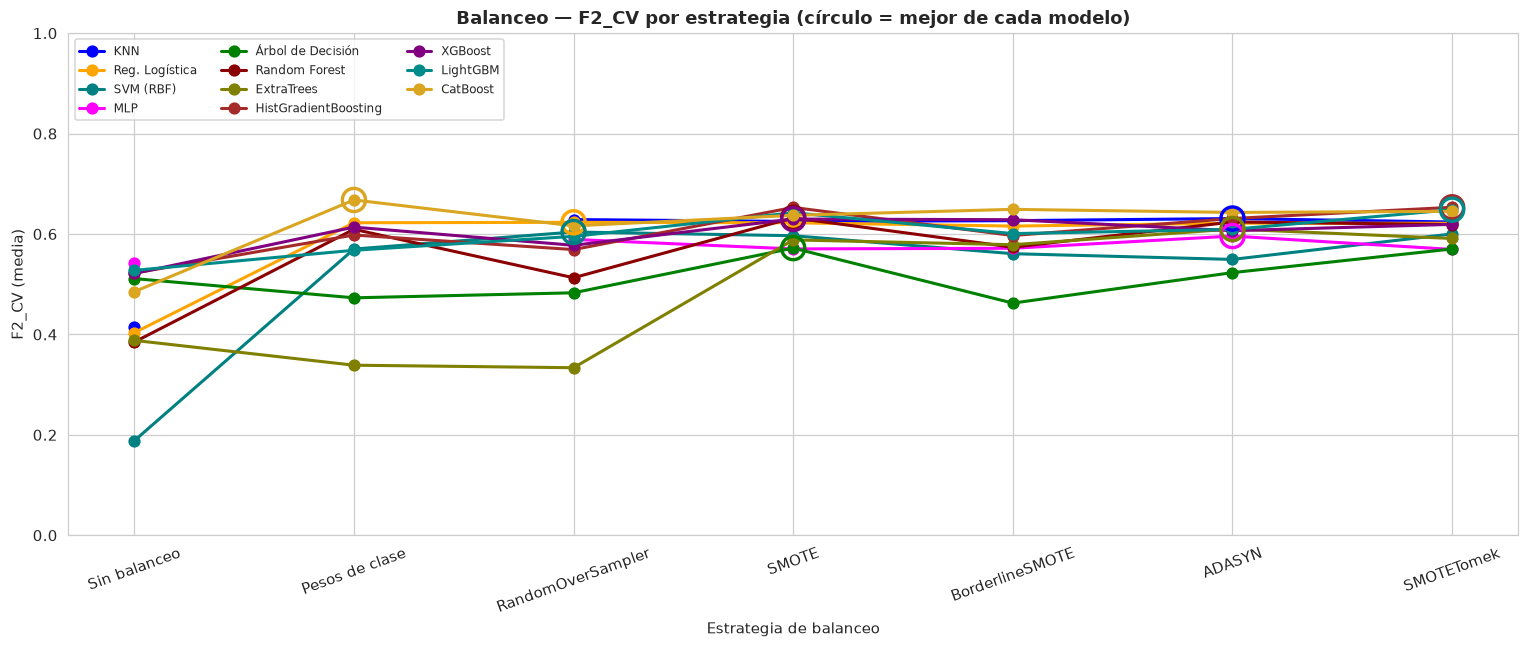

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(BALANCEADORES))
for mod in MODELOS:
    ax.plot(x, f2_bal[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = BALANCEADORES.index(mejor_bal_por_modelo[mod])
    ax.scatter([xi], [f2_bal.loc[mejor_bal_por_modelo[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(BALANCEADORES, rotation=20)
ax.set_xlabel('Estrategia de balanceo'); ax.set_ylabel('F2_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Balanceo — F2_CV por estrategia (círculo = mejor de cada modelo)', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/balanceo_f2_cv_comparacion.png', bbox_inches='tight'); plt.show()

## Análisis de Componentes Principales (PCA) por bloques geoquímicos

Se evalúa si la reducción de dimensionalidad mejora el F2\_CV de alguno de los 11 modelos. A diferencia de un PCA global sobre las 43 features, aquí el PCA se aplica **por bloques geoquímicos**: una proyección independiente para cada grupo — mayores (alteración), trazas inmóviles (litología), pathfinders (halo) y LILE — concatenando las componentes resultantes. Los 2 indicadores binarios (`Se_detectado`, `Te_detectado`) pasan sin transformar.

**¿Por qué por bloques y no global?** Un PCA global mezcla en una misma componente elementos de génesis distinta (p. ej. Al de la roca con As del halo hidrotermal), destruyendo por completo la interpretabilidad. El PCA por bloques conserva una lectura geológica: las componentes del bloque de mayores capturan variabilidad de alteración, las de inmóviles variabilidad litológica y las de pathfinders la estructura del halo.

Se barren 5 niveles de **varianza retenida por bloque** (70%, 80%, 90%, 95%, 99%), en dos escenarios:

1. **E1 — PCA por bloques sin balanceo.**
2. **E2 — PCA por bloques con la mejor estrategia de balanceo de cada modelo** (sección anterior).

Cada bloque se escala y proyecta **dentro** del pipeline, recalculándose en cada fold del CV para evitar fuga; el sobremuestreo (cuando aplica) se realiza en el espacio de componentes.

**Hipótesis:** los modelos basados en árboles de gradiente (XGBoost, LightGBM, CatBoost, HGB) no deberían beneficiarse de PCA, porque los árboles particionan por umbrales sobre features individuales — incluso por bloques, la rotación ortogonal diluye la semántica elemental de cada pathfinder.

In [12]:
# ── Bloques para PCA (los 4 grupos geoquímicos); indicadores binarios = passthrough ──
BLOQUES_PCA = {g: cols for g, cols in GRUPOS.items() if g != 'Indicadores de detección'}
COLS_PASSTHROUGH = GRUPOS['Indicadores de detección']
NIVELES_VAR = [0.70, 0.80, 0.90, 0.95, 0.99]

def construir_prep_bloques(var_retenida):
    '''ColumnTransformer: StandardScaler→PCA(var_retenida) por bloque geoquímico;
    indicadores binarios en passthrough. Se reajusta dentro de cada fold.'''
    transformadores = []
    for i, (g, cols) in enumerate(BLOQUES_PCA.items()):
        etiqueta = f'b{i}_' + g.split(' (')[0].lower().replace(' ', '_').replace('/', '_')
        transformadores.append((etiqueta,
                                Pipeline([('sc', StandardScaler()),
                                          ('pca', PCA(n_components=var_retenida, random_state=SEED))]),
                                cols))
    return ColumnTransformer(transformadores + [('ind', 'passthrough', COLS_PASSTHROUGH)])

def sustento_pca_bloque(Xtr_scaled):
    '''Descriptivo: var_acum, eigenvalues y umbrales n70/n80/n90/n95/n99 + Kaiser de un bloque.'''
    pca = PCA(random_state=SEED).fit(Xtr_scaled)
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    eigen = pca.explained_variance_
    n = {u: int(np.argmax(var_acum >= u) + 1) for u in NIVELES_VAR}
    n['kaiser'] = int(np.sum(eigen > 1))
    return var_acum, eigen, n

def barrido_pca_bloques_cv(balanceo_por_modelo):
    '''F2_CV para cada nivel de varianza retenida × modelo, con el balanceo indicado.'''
    tab = pd.DataFrame(index=NIVELES_VAR, columns=MODELOS, dtype=float)
    for u in NIVELES_VAR:
        for mod in MODELOS:
            bal = balanceo_por_modelo if isinstance(balanceo_por_modelo, str) else balanceo_por_modelo[mod]
            mu, _ = f2_cv(mod, balanceo=bal, prep=construir_prep_bloques(u))
            tab.loc[u, mod] = mu
        print(f'  varianza retenida {u:.0%} completada')
    return tab.astype(float).round(4)

def grafico_barrido(tab, titulo, fname):
    '''Gráfico de F2_CV vs varianza retenida por bloque para los 11 modelos.'''
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(tab.index))
    for mod in MODELOS:
        ax.plot(x, tab[mod].values, marker='o', ms=5, lw=1.8, color=MODEL_COLORS[mod], label=mod)
        xb = int(np.argmax(tab[mod].values))
        ax.scatter([xb], [tab[mod].max()], s=210, facecolors='none',
                   edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
    ax.set_xticks(x); ax.set_xticklabels([f'{u:.0%}' for u in tab.index])
    ax.set_xlabel('Varianza retenida por bloque'); ax.set_ylabel('F2_CV (media)'); ax.set_ylim(0, 1)
    ax.set_title(titulo, fontweight='bold'); ax.legend(fontsize=8, ncol=3)
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()

print('Funciones de PCA por bloques listas.')

Funciones de PCA por bloques listas.


### Sustento: varianza explicada por bloque

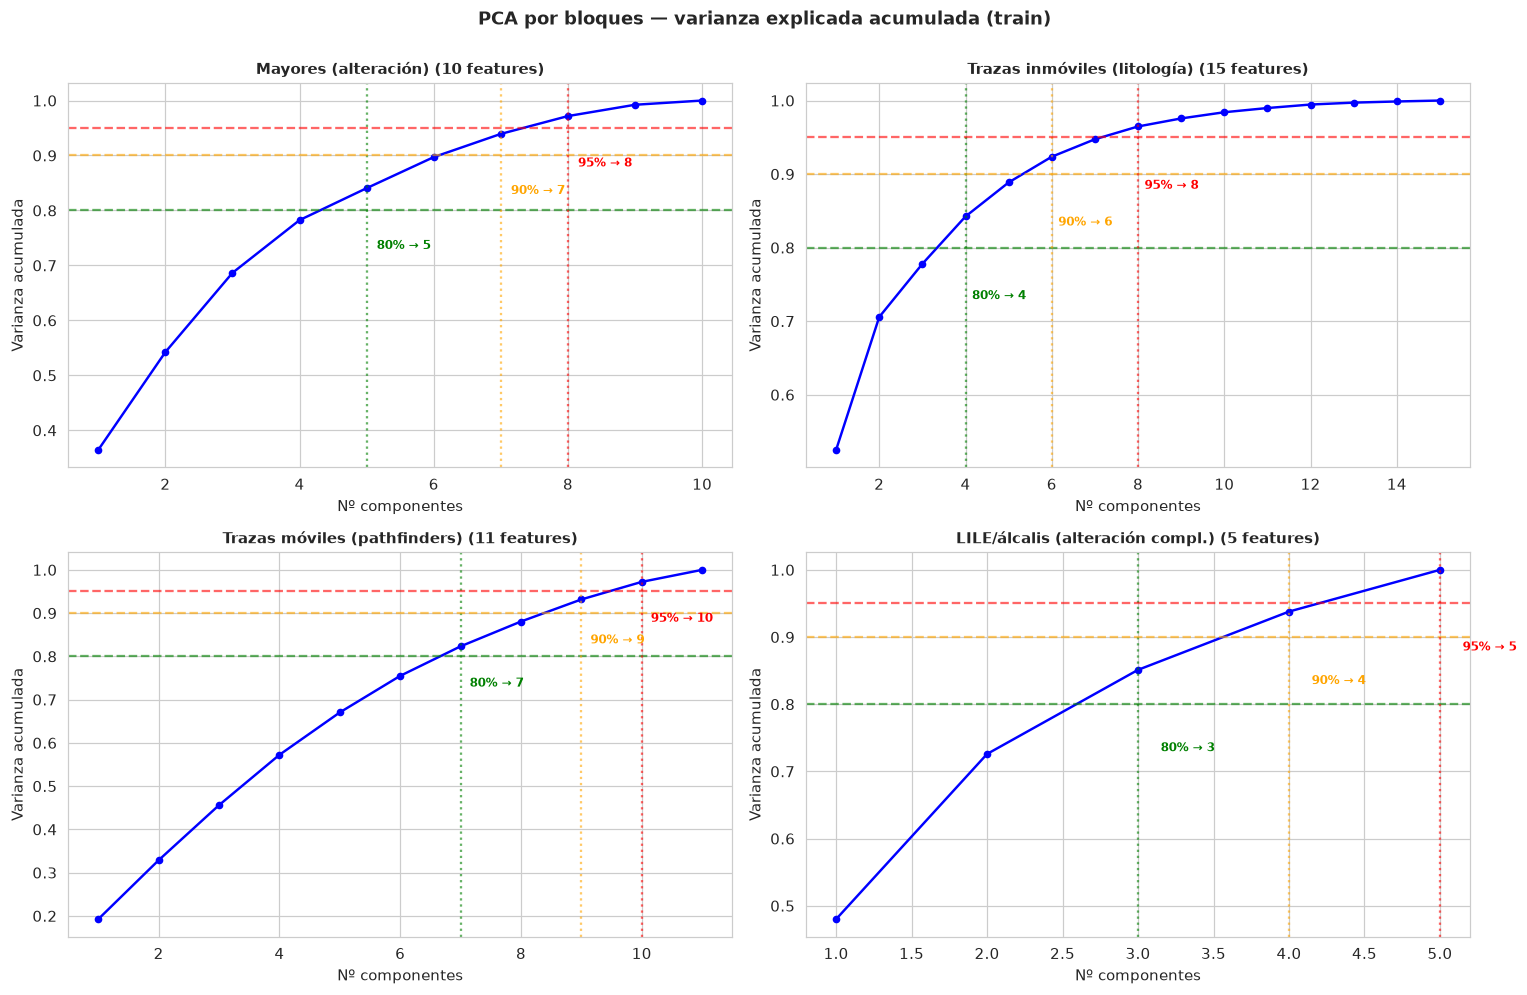

Nº de componentes por bloque para cada nivel de varianza retenida:


,Bloque,Features,Kaiser,70%,80%,90%,95%,99%
0,Mayores (alteración),10,3,4,5,7,8,9
1,Trazas inmóviles (litología),15,3,2,4,6,8,12
2,Trazas móviles (pathfinders),11,5,6,7,9,10,11
3,LILE/álcalis (alteración compl.),5,2,2,3,4,5,5


In [13]:
# ── Varianza acumulada y scree plot por bloque geoquímico (descriptivo, solo train) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
filas_sust = []
for ax, (g, cols) in zip(axes.ravel(), BLOQUES_PCA.items()):
    Xb = StandardScaler().fit_transform(X_train[cols])
    va, eig, n = sustento_pca_bloque(Xb)
    comp = np.arange(1, len(va) + 1)
    ax.plot(comp, va, marker='o', ms=4, color='blue', lw=1.6)
    for u, c in [(0.80, 'green'), (0.90, 'orange'), (0.95, 'red')]:
        ax.axhline(u, ls='--', color=c, alpha=.6)
        ax.axvline(n[u], ls=':', color=c, alpha=.6)
        ax.text(n[u] + 0.15, u - 0.07, f'{int(u*100)}% → {n[u]}', color=c, fontweight='bold', fontsize=8)
    ax.set_title(f'{g} ({len(cols)} features)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Nº componentes'); ax.set_ylabel('Varianza acumulada')
    filas_sust.append({'Bloque': g, 'Features': len(cols), 'Kaiser': n['kaiser'],
                       **{f'{int(u*100)}%': n[u] for u in NIVELES_VAR}})
plt.suptitle('PCA por bloques — varianza explicada acumulada (train)', fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/PCA_bloques_sustento.png', bbox_inches='tight'); plt.show()

tabla_sustento = pd.DataFrame(filas_sust)
tabla_sustento.to_csv(f'{DIR_TAB}/PCA_bloques_sustento.csv', index=False)
print('Nº de componentes por bloque para cada nivel de varianza retenida:')
tabla_sustento

### Barrido E1 — PCA por bloques sin balanceo

Barrido PCA por bloques E1 (sin balanceo) por F2_CV ...
  varianza retenida 70% completada
  varianza retenida 80% completada
  varianza retenida 90% completada
  varianza retenida 95% completada
  varianza retenida 99% completada
  hecho en 128s


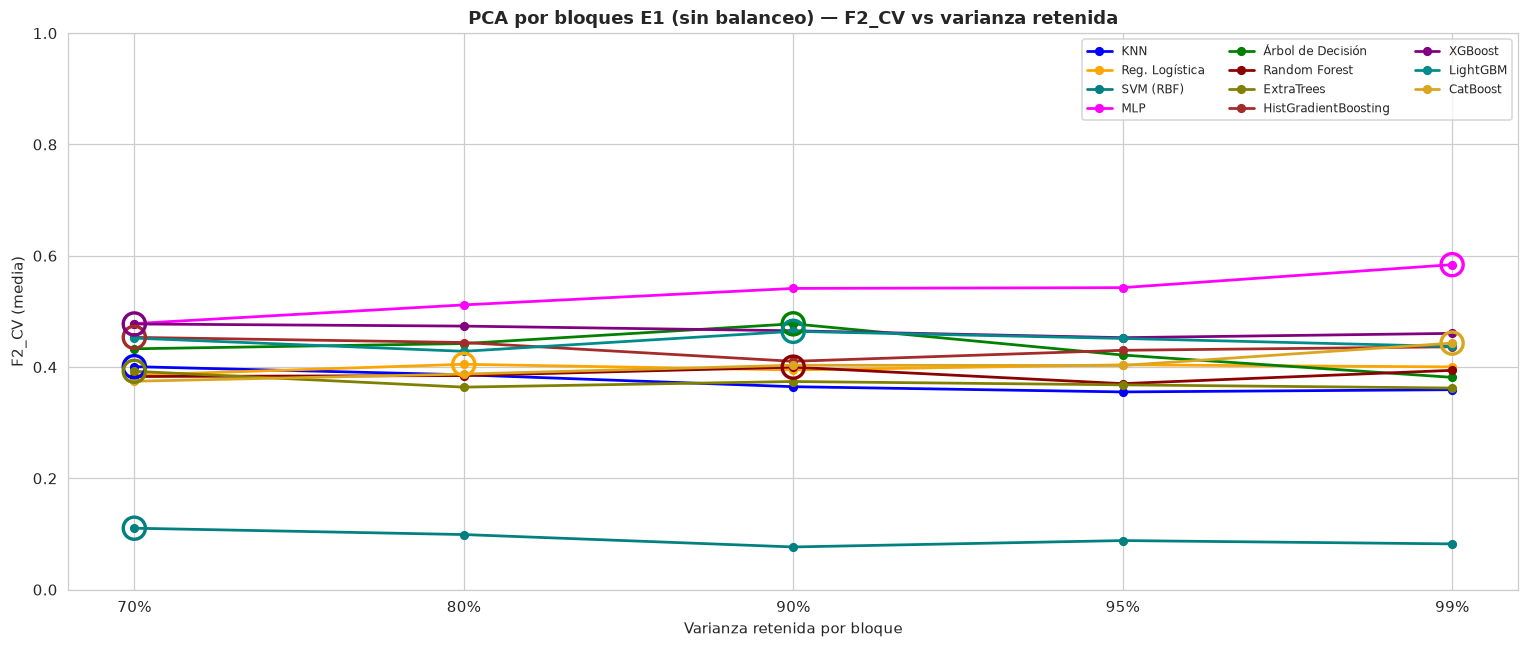

F2_CV por nivel de varianza retenida (E1):


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
0.700000,0.4007,0.3855,0.1104,0.4781,0.4328,0.3830,0.3924,0.4534,0.4774,0.4520,0.3745
0.800000,0.3861,0.4050,0.0990,0.5117,0.4422,0.3847,0.3639,0.4441,0.4736,0.4283,0.3874
0.900000,0.3647,0.3948,0.0767,0.5413,0.4777,0.3998,0.3740,0.4103,0.4652,0.4642,0.4033
0.950000,0.3553,0.4040,0.0882,0.5427,0.4216,0.3702,0.3680,0.4301,0.4528,0.4514,0.4028
0.990000,0.3593,0.4003,0.0822,0.5840,0.3815,0.3941,0.3623,0.4364,0.4605,0.4370,0.4430


In [14]:
print('Barrido PCA por bloques E1 (sin balanceo) por F2_CV ...')
t0 = time.time()
tab_pca_e1 = barrido_pca_bloques_cv('Sin balanceo')
print(f'  hecho en {time.time()-t0:.0f}s')
tab_pca_e1.to_csv(f'{DIR_TAB}/PCA_bloques_sinbalanceo_f2_cv.csv')
grafico_barrido(tab_pca_e1, 'PCA por bloques E1 (sin balanceo) — F2_CV vs varianza retenida',
                f'{DIR_FIG}/PCA_bloques_sinbalanceo_f2_cv.png')
print('F2_CV por nivel de varianza retenida (E1):')
tab_pca_e1.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

### Barrido E2 — PCA por bloques con el mejor balanceo de cada modelo

Mejor balanceo por modelo: {'KNN': 'ADASYN', 'Reg. Logística': 'RandomOverSampler', 'SVM (RBF)': 'RandomOverSampler', 'MLP': 'ADASYN', 'Árbol de Decisión': 'SMOTE', 'Random Forest': 'SMOTE', 'ExtraTrees': 'ADASYN', 'HistGradientBoosting': 'SMOTETomek', 'XGBoost': 'SMOTE', 'LightGBM': 'SMOTETomek', 'CatBoost': 'Pesos de clase'}
Barrido PCA por bloques E2 (con mejor balanceo por modelo) por F2_CV ...
  varianza retenida 70% completada
  varianza retenida 80% completada
  varianza retenida 90% completada
  varianza retenida 95% completada
  varianza retenida 99% completada
  hecho en 172s


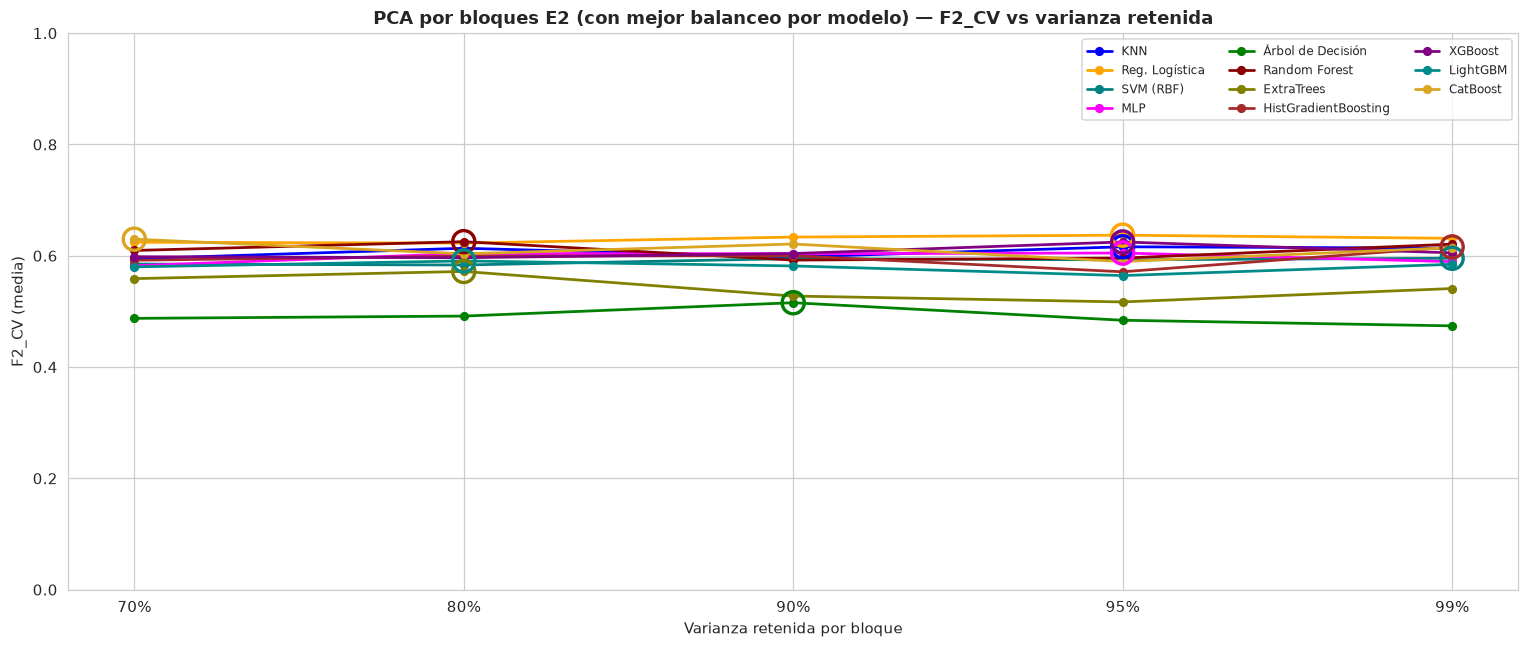

F2_CV por nivel de varianza retenida (E2):


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
0.700000,0.5946,0.6243,0.5851,0.5821,0.4875,0.6095,0.5589,0.5920,0.5983,0.5800,0.6298
0.800000,0.6135,0.6227,0.5834,0.6040,0.4916,0.6253,0.5718,0.5992,0.5965,0.5907,0.6035
0.900000,0.5977,0.6336,0.5949,0.6037,0.5156,0.5922,0.5276,0.6001,0.6040,0.5817,0.6211
0.950000,0.6161,0.6370,0.5926,0.6049,0.4841,0.5958,0.5170,0.5712,0.6248,0.5644,0.5897
0.990000,0.6137,0.6313,0.5955,0.5894,0.4740,0.6209,0.5411,0.6158,0.6052,0.5846,0.6145


In [15]:
print('Mejor balanceo por modelo:', mejor_bal_por_modelo)
print('Barrido PCA por bloques E2 (con mejor balanceo por modelo) por F2_CV ...')
t0 = time.time()
tab_pca_e2 = barrido_pca_bloques_cv(mejor_bal_por_modelo)
print(f'  hecho en {time.time()-t0:.0f}s')
tab_pca_e2.to_csv(f'{DIR_TAB}/PCA_bloques_conbalanceo_f2_cv.csv')
grafico_barrido(tab_pca_e2, 'PCA por bloques E2 (con mejor balanceo por modelo) — F2_CV vs varianza retenida',
                f'{DIR_FIG}/PCA_bloques_conbalanceo_f2_cv.png')
print('F2_CV por nivel de varianza retenida (E2):')
tab_pca_e2.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

## Comparativo final

Se comparan 4 configuraciones para cada modelo, todas decididas por F2\_CV:

| Config | Descripción |
|---|---|
| (1) Baseline | Sprint 0: sin balanceo, sin PCA |
| (2) Balanceo | Mejor estrategia de balanceo del barrido anterior |
| (3) PCA bloques | Mejor varianza retenida sin balanceo |
| (4) Bal+PCA | Mejor varianza retenida con el mejor balanceo |

La configuración ganadora de cada modelo se selecciona como la de mayor F2\_CV. Si el balanceo mejora y PCA no, la conclusión será que **las features originales con su semántica geoquímica son más informativas que las componentes principales**, incluso proyectadas por bloques.

In [16]:
filas_f2 = {}
detalle = {}
for mod in MODELOS:
    met = mejor_bal_por_modelo[mod]
    u3 = float(tab_pca_e1[mod].idxmax())
    u4 = float(tab_pca_e2[mod].idxmax())
    f2_base, _  = f2_cv(mod, balanceo='Sin balanceo')
    f2_bal_v, _ = f2_cv(mod, balanceo=met)
    f2_pca, _   = f2_cv(mod, balanceo='Sin balanceo', prep=construir_prep_bloques(u3))
    f2_bp, _    = f2_cv(mod, balanceo=met, prep=construir_prep_bloques(u4))
    filas_f2[mod] = {'(1) Baseline': round(f2_base, 4), '(2) Balanceo': round(f2_bal_v, 4),
                     '(3) PCA bloques': round(f2_pca, 4), '(4) Bal+PCA': round(f2_bp, 4)}
    detalle[mod] = {'_meta': {'metodo': met, 'var_pca_solo': u3, 'var_pca_bal': u4},
                    'config_kwargs': {'(1) Baseline': dict(balanceo='Sin balanceo', prep=None),
                                      '(2) Balanceo': dict(balanceo=met, prep=None),
                                      '(3) PCA bloques': dict(balanceo='Sin balanceo', prep=construir_prep_bloques(u3)),
                                      '(4) Bal+PCA': dict(balanceo=met, prep=construir_prep_bloques(u4))}}
print('Configuraciones evaluadas por F2_CV.')
for mod in MODELOS:
    mt = detalle[mod]['_meta']
    print(f"  {mod}: balanceo={mt['metodo']} | PCA solo={mt['var_pca_solo']:.0%} | Bal+PCA={mt['var_pca_bal']:.0%}")

Configuraciones evaluadas por F2_CV.
  KNN: balanceo=ADASYN | PCA solo=70% | Bal+PCA=95%
  Reg. Logística: balanceo=RandomOverSampler | PCA solo=80% | Bal+PCA=95%
  SVM (RBF): balanceo=RandomOverSampler | PCA solo=70% | Bal+PCA=99%
  MLP: balanceo=ADASYN | PCA solo=99% | Bal+PCA=95%
  Árbol de Decisión: balanceo=SMOTE | PCA solo=90% | Bal+PCA=90%
  Random Forest: balanceo=SMOTE | PCA solo=90% | Bal+PCA=80%
  ExtraTrees: balanceo=ADASYN | PCA solo=70% | Bal+PCA=80%
  HistGradientBoosting: balanceo=SMOTETomek | PCA solo=70% | Bal+PCA=99%
  XGBoost: balanceo=SMOTE | PCA solo=70% | Bal+PCA=95%
  LightGBM: balanceo=SMOTETomek | PCA solo=90% | Bal+PCA=80%
  CatBoost: balanceo=Pesos de clase | PCA solo=99% | Bal+PCA=70%


In [17]:
tab_f2_evol = pd.DataFrame(filas_f2).T.round(4)
tab_f2_evol.to_csv(f'{DIR_TAB}/final_evolucion_f2_cv.csv')

print('Evolución de F2_CV por configuración (decisión):')
tab_f2_evol.style.apply(resaltar_maximo_fila, axis=1).format('{:.4f}')

Evolución de F2_CV por configuración (decisión):


,(1) Baseline,(2) Balanceo,(3) PCA bloques,(4) Bal+PCA
KNN,0.4149,0.6308,0.4007,0.6161
Reg. Logística,0.4034,0.6233,0.4050,0.6370
SVM (RBF),0.1883,0.6040,0.1104,0.5955
MLP,0.5432,0.5959,0.5840,0.6049
Árbol de Decisión,0.5112,0.5719,0.4777,0.5156
Random Forest,0.3848,0.6322,0.3998,0.6253
ExtraTrees,0.3881,0.6099,0.3924,0.5718
HistGradientBoosting,0.5223,0.6532,0.4534,0.6158
XGBoost,0.5214,0.6298,0.4774,0.6248
LightGBM,0.5276,0.6484,0.4642,0.5907


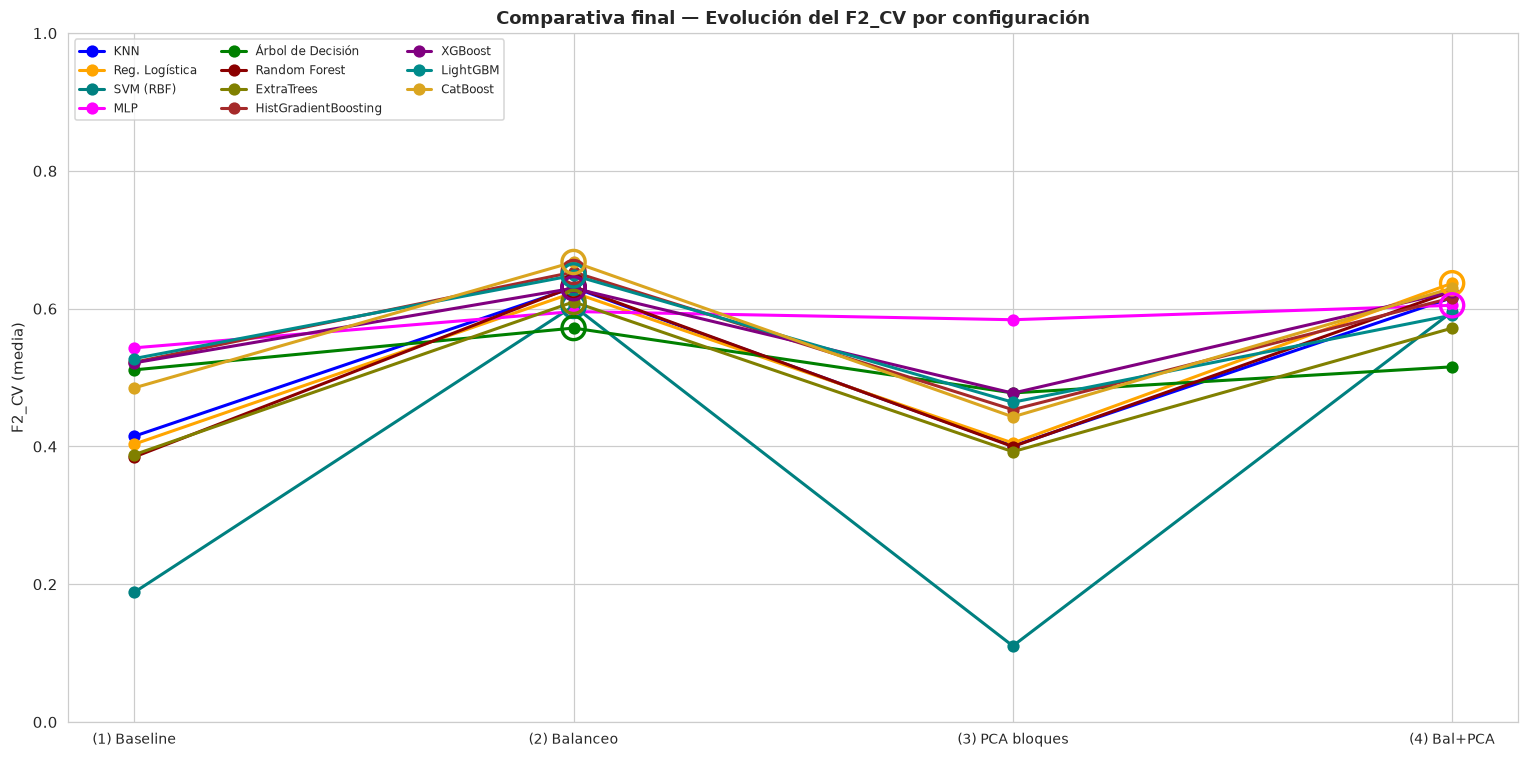

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))
configs = list(next(iter(filas_f2.values())).keys())
x = np.arange(len(configs))
for mod in MODELOS:
    vals = [filas_f2[mod][c] for c in configs]
    ax.plot(x, vals, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xb = int(np.argmax(vals))
    ax.scatter([xb], [vals[xb]], s=230, facecolors='none', edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('F2_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Comparativa final — Evolución del F2_CV por configuración', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/final_evolucion_f2_cv.png', bbox_inches='tight'); plt.show()

## Evaluación en hold-out (informativa)

El hold-out se evalúa **una sola vez**, con la configuración ganadora de cada modelo (ya elegida por F2\_CV). Estas métricas son informativas y **no influyen en ninguna decisión**.

In [19]:
mejor_cfg_por_mod = {mod: max(filas_f2[mod], key=filas_f2[mod].get) for mod in MODELOS}
f2cv_por_mod = {mod: filas_f2[mod][mejor_cfg_por_mod[mod]] for mod in MODELOS}

METRICAS = ['F2', 'Recall', 'Precision', 'F1', 'Accuracy', 'AUC-ROC', 'AUC-PR']
res_ho = {}
modelos_fit_s1 = {}
for mod in MODELOS:
    kwargs = detalle[mod]['config_kwargs'][mejor_cfg_por_mod[mod]]
    res_ho[mod] = evaluar_holdout(mod, **kwargs)
    modelos_fit_s1[mod] = res_ho[mod].pop('_pipe')
tabla_ho = pd.DataFrame({m: {k: res_ho[m][k] for k in METRICAS} for m in MODELOS}).T[METRICAS].round(4)
tabla_ho['Config (por F2_CV)'] = [mejor_cfg_por_mod[m] for m in MODELOS]
tabla_ho.to_csv(f'{DIR_TAB}/final_holdout_metricas.csv')

print('Métricas en HOLD-OUT (informativas — la config ya se eligió por F2_CV)')
tabla_ho.style.apply(resaltar_maximo, axis=0, subset=METRICAS).format('{:.4f}', subset=METRICAS)

Métricas en HOLD-OUT (informativas — la config ya se eligió por F2_CV)


,F2,Recall,Precision,F1,Accuracy,AUC-ROC,AUC-PR,Config (por F2_CV)
KNN,0.6515,0.8269,0.3525,0.4943,0.7939,0.8328,0.3454,(2) Balanceo
Reg. Logística,0.6344,0.8077,0.3415,0.4800,0.7869,0.8995,0.6075,(4) Bal+PCA
SVM (RBF),0.6079,0.7692,0.3306,0.4624,0.7822,0.8937,0.6008,(2) Balanceo
MLP,0.6178,0.6154,0.6275,0.6214,0.9087,0.8857,0.6724,(4) Bal+PCA
Árbol de Decisión,0.5282,0.5769,0.3947,0.4688,0.8407,0.7271,0.2793,(2) Balanceo
Random Forest,0.6481,0.6731,0.5645,0.6140,0.8970,0.9159,0.6149,(2) Balanceo
ExtraTrees,0.5792,0.5769,0.5882,0.5825,0.8993,0.9055,0.6306,(2) Balanceo
HistGradientBoosting,0.6395,0.6346,0.6600,0.6471,0.9157,0.9353,0.7356,(2) Balanceo
XGBoost,0.7143,0.7500,0.6000,0.6667,0.9087,0.9290,0.7374,(2) Balanceo
LightGBM,0.6955,0.7115,0.6379,0.6727,0.9157,0.9383,0.7525,(2) Balanceo


## Persistencia de artefactos

Se guardan los 11 pipelines ajustados (cada uno con su mejor configuración de balanceo) para que el Sprint 2 los cargue directamente sin reconstruirlos.

In [20]:
modelos_guardados_s1 = {}
for mod, pipe in modelos_fit_s1.items():
    fname = 'modelo_' + (mod.replace(' ', '_').replace('(', '').replace(')', '')
                          .replace('.', '').replace('á', 'a').replace('é', 'e')
                          .replace('í', 'i').replace('ó', 'o')) + '.pkl'
    ruta = f'{DIR_MODELS}/{fname}'
    joblib.dump(pipe, ruta)
    modelos_guardados_s1[mod] = ruta
print(f'{len(modelos_guardados_s1)} modelos guardados en {DIR_MODELS}/')

11 modelos guardados en outputs_sprint1/models/


## Conclusión sobre PCA

El barrido por bloques geoquímicos (5 niveles de varianza retenida × 11 modelos × 2 escenarios) permite responder si la reducción de dimensionalidad aporta al F2\_CV. La conclusión se sustenta en la tabla comparativa final: la configuración ganadora de cada modelo indica si PCA entra o no en el pipeline del Sprint 2.

- Los **árboles de gradiente** (XGBoost, LightGBM, CatBoost, HGB) particionan por umbrales sobre features individuales. Incluso proyectando por bloques, la rotación ortogonal mezcla la señal de los pathfinders (As, Sb, Te...) en componentes compuestas, diluyendo los umbrales de anomalía que el árbol necesita aislar.
- Los modelos sensibles a escala (KNN, SVM, MLP, LogReg) podrían beneficiarse de la decorrelación dentro de cada bloque, a costa de perder la señal contenida en las componentes menores.

**Decisión (por F2\_CV, tabla comparativa final): PCA por bloques solo mejora marginalmente a 2 de los 11 modelos (Reg. Logística: 0.6233 → 0.6370 con 95% de varianza; MLP: 0.5959 → 0.6049), y empeora o no aporta en los 9 restantes — en particular en todos los árboles de gradiente, confirmando la hipótesis. El ganador global (CatBoost, F2\_CV = 0.6678) no usa PCA. **Se descarta PCA como transformación general y se continúa con las 43 features originales + la mejor estrategia de balanceo de cada modelo.****

## Resumen

In [22]:
mejor_modelo = max(f2cv_por_mod, key=f2cv_por_mod.get)
cfg_mejor = mejor_cfg_por_mod[mejor_modelo]
met_mejor = detalle[mejor_modelo]['_meta']['metodo'] if cfg_mejor in ('(2) Balanceo', '(4) Bal+PCA') else 'Sin balanceo'
f2cv_mejor = f2cv_por_mod[mejor_modelo]
f2ho_mejor = round(float(res_ho[mejor_modelo]['F2']), 4)
recall_ho_mejor = round(float(res_ho[mejor_modelo]['Recall']), 4)

resumen1 = {
    'sprint': 1,
    'nombre': 'Balanceo de clases y PCA por bloques geoquímicos',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': ('Decisión por F2_CV 5-fold con balanceo/PCA dentro de cada fold (ImbPipeline); '
                  'pesos de clase como estrategia candidata; PCA por bloques geoquímicos; '
                  'hold-out evaluado una sola vez y solo informativo.'),
    'metrica_decision': 'f2',
    'metrica_principal': 'recall',
    'mejor_modelo': mejor_modelo,
    'mejor_config': cfg_mejor,
    'metodo_balanceo': met_mejor,
    'f2_cv_final': round(f2cv_mejor, 4),
    'f2_holdout': f2ho_mejor,
    'f2_final': round(f2cv_mejor, 4),
    'f2_sprint0': F2_SPRINT0,
    'mejora_vs_sprint0': round(f2cv_mejor - F2_SPRINT0, 4),
    'metricas_holdout': {m: round(float(res_ho[mejor_modelo][m]), 4) for m in METRICAS},
    'f2_cv_por_modelo': {m: round(float(f2cv_por_mod[m]), 4) for m in MODELOS},
    'f2_holdout_por_modelo': {m: round(float(res_ho[m]['F2']), 4) for m in MODELOS},
    'recall_holdout_por_modelo': {m: round(float(res_ho[m]['Recall']), 4) for m in MODELOS},
    'config_por_modelo': mejor_cfg_por_mod,
    'balanceo_por_modelo': mejor_bal_por_modelo,
    'var_pca_por_modelo': {m: detalle[m]['_meta'] | {} for m in MODELOS},
    'modelos_guardados': modelos_guardados_s1,
    'n_modelos': len(MODELOS),
    'n_features': len(FEATURES),
    'features': FEATURES,
    'grupos_geoquimicos': GRUPOS,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
# serializar _meta como dict simple
resumen1['var_pca_por_modelo'] = {m: {'metodo': detalle[m]['_meta']['metodo'],
                                      'var_pca_solo': detalle[m]['_meta']['var_pca_solo'],
                                      'var_pca_bal': detalle[m]['_meta']['var_pca_bal']} for m in MODELOS}
with open(f'{OUT}/resumen_sprint1.json', 'w') as f:
    json.dump(resumen1, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 1 ════════════════════')
print(f'Balanceo y PCA por bloques decididos por F2_CV ({len(MODELOS)} modelos)')
for mod in MODELOS:
    f2_base = RESUMEN_S0['f2_cv_por_modelo'].get(mod, filas_f2[mod]['(1) Baseline'])
    marca = ' ← GANADOR' if mod == mejor_modelo else ''
    print(f'  {mod:22s}: S0={f2_base:.4f} → {mejor_cfg_por_mod[mod]}={f2cv_por_mod[mod]:.4f} '
          f'(Δ={f2cv_por_mod[mod]-f2_base:+.4f}){marca}')
print(coral(f'\nGANADOR: {mejor_modelo} ({cfg_mejor}, {met_mejor})'))
print(coral(f'   F2_CV       = {f2cv_mejor:.4f}   (decisión)'))
print(f'   F2 hold-out = {f2ho_mejor:.4f} | Recall hold-out = {recall_ho_mejor:.4f}   (informativo)')
print(f'\nEvolución del proyecto (por F2_CV):')
print(f'   Sprint 0 = {F2_SPRINT0:.4f} (baseline, {RESUMEN_S0["mejor_modelo"]})')
print(coral(f'   Sprint 1 = {f2cv_mejor:.4f} ({f2cv_mejor-F2_SPRINT0:+.4f}) — {mejor_modelo} + {cfg_mejor}'))
print(f'\n{len(modelos_guardados_s1)} modelos persistidos en {DIR_MODELS}/')
print('Resumen unificado: outputs_sprint1/resumen_sprint1.json')
print('\nSiguiente (Sprint 2): FE epitermal con bibliografía, clustering CLR y Optuna (decisión por F2_CV).')

════════════════════ RESUMEN SPRINT 1 ════════════════════
Balanceo y PCA por bloques decididos por F2_CV (11 modelos)
  KNN                   : S0=0.4149 → (2) Balanceo=0.6308 (Δ=+0.2159)
  Reg. Logística        : S0=0.4034 → (4) Bal+PCA=0.6370 (Δ=+0.2336)
  SVM (RBF)             : S0=0.1883 → (2) Balanceo=0.6040 (Δ=+0.4157)
  MLP                   : S0=0.5432 → (4) Bal+PCA=0.6049 (Δ=+0.0617)
  Árbol de Decisión     : S0=0.5112 → (2) Balanceo=0.5719 (Δ=+0.0607)
  Random Forest         : S0=0.3848 → (2) Balanceo=0.6322 (Δ=+0.2474)
  ExtraTrees            : S0=0.3881 → (2) Balanceo=0.6099 (Δ=+0.2218)
  HistGradientBoosting  : S0=0.5223 → (2) Balanceo=0.6532 (Δ=+0.1309)
  XGBoost               : S0=0.5214 → (2) Balanceo=0.6298 (Δ=+0.1084)
  LightGBM              : S0=0.5276 → (2) Balanceo=0.6484 (Δ=+0.1208)
  CatBoost              : S0=0.4851 → (2) Balanceo=0.6678 (Δ=+0.1827) ← GANADOR

GANADOR: CatBoost ((2) Balanceo, Pesos de clase)
   F2_CV       = 0.6678   (decisión)
   F2 hold-out =